## 데이터 로드

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
font_path = 'C:/Windows/Fonts/malgun.ttf'
font_name = fm.FontProperties(fname=font_path).get_name()
plt.rc('font', family=font_name)
plt.rc('axes', unicode_minus=False)

import geopandas as gpd


In [3]:
df_od = pd.read_csv(r"C:\Users\legen\Desktop\Lab Project\BC\data\market_od_all_oof.csv", encoding = 'utf-8-sig')

## 유휴부지

In [ ]:
df_vacant = pd.read_csv(r"D:\PP\BC\data\og\location mapping\경주 부지\국가철도공단_철도 유휴부지_20240619.csv", encoding='cp949')

### 위도 경도 맵핑

In [11]:
import pandas as pd
import numpy as np
import requests
import time

# 카카오맵 API 키
API_KEY = "c4ec06aea3a95e92e9a13e9a748872bf"

def kakao_geocode_address(query: str, api_key: str, timeout: int = 10):
    """주소(query) -> (lat, lon). 실패시 (np.nan, np.nan)"""
    if query is None or (isinstance(query, float) and np.isnan(query)):
        return np.nan, np.nan
    q = str(query).strip()
    if not q:
        return np.nan, np.nan

    headers = {"Authorization": f"KakaoAK {api_key}"}

    r = requests.get(
        "https://dapi.kakao.com/v2/local/search/address.json",
        headers=headers, params={"query": q}, timeout=timeout
    )
    if r.status_code == 200:
        docs = r.json().get("documents", [])
        if docs:
            x, y = docs[0].get("x"), docs[0].get("y")  # x=경도, y=위도
            if x and y:
                return float(y), float(x)

    # 주소 실패 시 키워드 fallback (보조)
    r2 = requests.get(
        "https://dapi.kakao.com/v2/local/search/keyword.json",
        headers=headers, params={"query": q}, timeout=timeout
    )
    if r2.status_code == 200:
        docs2 = r2.json().get("documents", [])
        if docs2:
            x, y = docs2[0].get("x"), docs2[0].get("y")
            if x and y:
                return float(y), float(x)

    return np.nan, np.nan


def add_latlon_to_vacant(df_vacant: pd.DataFrame, api_key: str,
                         addr_col: str = "재산 소재지",
                         lat_col: str = "lat",
                         lon_col: str = "lon",
                         sleep: float = 0.15,
                         verbose: bool = True):
    out = df_vacant.copy()
    if lat_col not in out.columns: out[lat_col] = np.nan
    if lon_col not in out.columns: out[lon_col] = np.nan

    # 좌표 없는 행만
    mask = out[lat_col].isna() | out[lon_col].isna()
    idxs = out.index[mask].tolist()

    if verbose:
        print(f"지오코딩 대상: {len(idxs)}")

    for k, idx in enumerate(idxs, start=1):
        addr = out.at[idx, addr_col]
        lat, lon = kakao_geocode_address(addr, api_key=api_key)
        out.at[idx, lat_col] = lat
        out.at[idx, lon_col] = lon

        if verbose:
            print(f"[{k}/{len(idxs)}] {'OK' if not np.isnan(lat) else 'FAIL'} | {addr}")

        time.sleep(sleep)

    return out

In [12]:
kj_vacant = df_vacant[df_vacant["재산 소재지"].str.contains("경주시", na=False)].copy()

In [ ]:
#kj_vacant = add_latlon_to_vacant(kj_vacant, api_key=API_KEY, addr_col="재산 소재지")

지오코딩 대상: 4101
[1/4101] OK | 경상북도 경주시 강동면 양동리 1004-16
[2/4101] OK | 경상북도 경주시 강동면 양동리 421-3
[3/4101] OK | 경상북도 경주시 강동면 양동리 421-4
[4/4101] OK | 경상북도 경주시 강동면 양동리 421-5
[5/4101] OK | 경상북도 경주시 강동면 양동리 423-2
[6/4101] OK | 경상북도 경주시 강동면 양동리 423-3
[7/4101] OK | 경상북도 경주시 강동면 양동리 425-3
[8/4101] OK | 경상북도 경주시 강동면 양동리 425-5
[9/4101] OK | 경상북도 경주시 강동면 양동리 425-7
[10/4101] OK | 경상북도 경주시 강동면 양동리 426-2
[11/4101] OK | 경상북도 경주시 강동면 양동리 427-1
[12/4101] OK | 경상북도 경주시 강동면 양동리 439-2
[13/4101] OK | 경상북도 경주시 강동면 양동리 439-4
[14/4101] OK | 경상북도 경주시 강동면 양동리 440-2
[15/4101] OK | 경상북도 경주시 강동면 양동리 441-2
[16/4101] OK | 경상북도 경주시 강동면 양동리 441-3
[17/4101] OK | 경상북도 경주시 강동면 양동리 442-2
[18/4101] OK | 경상북도 경주시 강동면 양동리 442-4
[19/4101] OK | 경상북도 경주시 강동면 양동리 443-2
[20/4101] OK | 경상북도 경주시 강동면 양동리 444-2
[21/4101] OK | 경상북도 경주시 강동면 양동리 451-2
[22/4101] OK | 경상북도 경주시 강동면 양동리 451-4
[23/4101] OK | 경상북도 경주시 강동면 양동리 452-1
[24/4101] OK | 경상북도 경주시 강동면 양동리 453-1
[25/4101] OK | 경상북도 경주시 강동면 양동리 453-2
[26/4101] OK | 경상북도 경주시 강동면 양동리 454-2
[27/4

In [ ]:
#kj_vacant.to_csv(r"C:\Users\legen\Desktop\Lab Project\BC\modeling\kj_vacant.csv", encoding = 'utf-8-sig', index_label=False)

## 후보지 추출

In [2]:
kj_vacant = pd.read_csv(r"C:\Users\legen\Desktop\Lab Project\BC\modeling\kj_vacant.csv", encoding = 'utf-8-sig')

In [3]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point

LI_SHP_PATH = r"D:\PP\BC\data\og\li.shp"

market_lat, market_lon = 35.894715, 129.048453

INNER_R = 300
OUTER_R = 800

MIN_AREA = 450
USE_ONLY_UNUSED = True

# 1) 리 경계
g_li = gpd.read_file(LI_SHP_PATH, encoding="cp949")
g_li = g_li.set_crs("EPSG:5179") if g_li.crs is None else g_li.to_crs("EPSG:5179")

# 2) 시장점(4326 -> 5179)
g_market = gpd.GeoDataFrame(
    {"market": ["서면시장"]},
    geometry=[Point(market_lon, market_lat)],
    crs="EPSG:4326"
).to_crs("EPSG:5179")

# 3) 300~800m 링
buf800 = g_market.buffer(OUTER_R).iloc[0]
buf300 = g_market.buffer(INNER_R).iloc[0]
ring = buf800.difference(buf300)

# 4) 후보 DF 정리
df = kj_vacant.copy()
df = df.dropna(subset=["lat","lon"]).copy()

if MIN_AREA and ("공부상 면적" in df.columns):
    df = df[df["공부상 면적"] >= MIN_AREA].copy()

if USE_ONLY_UNUSED and ("사용여부" in df.columns):
    df = df[df["사용여부"].astype(str).str.contains("미사용", na=False)].copy()

# 5) 후보 GeoDF(4326 -> 5179)
g_fac = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["lon"], df["lat"]),
    crs="EPSG:4326"
).to_crs("EPSG:5179")

# 6) 링 내 후보
g_fac_in_ring = g_fac[g_fac.intersects(ring)].copy()

# 7) 직선거리(참고)
mx, my = g_market.geometry.iloc[0].x, g_market.geometry.iloc[0].y
g_fac_in_ring["euclid_m"] = g_fac_in_ring.geometry.distance(Point(mx, my))

print("[후보 추출] 링 내 후보:", len(g_fac_in_ring))
display(g_fac_in_ring[["재산 소재지","공부상 면적","사용여부","euclid_m"]].head(10))


[후보 추출] 링 내 후보: 24


,재산 소재지,공부상 면적,사용여부,euclid_m
17409,경상북도 경주시 서면 도계리 9-3,1355.0,미사용,755.723416
17452,경상북도 경주시 서면 아화리 1214-15,645.0,미사용,567.904152
17466,경상북도 경주시 서면 아화리 223-3,1345.0,미사용,560.449610
17467,경상북도 경주시 서면 아화리 224,506.0,미사용,492.961759
17468,경상북도 경주시 서면 아화리 225-2,509.0,미사용,502.991023
17476,경상북도 경주시 서면 아화리 377-43,1164.0,미사용,605.991975
17490,경상북도 경주시 서면 아화리 411-21,1226.0,미사용,380.552390
17496,경상북도 경주시 서면 아화리 415-17,642.0,미사용,569.880413
17501,경상북도 경주시 서면 아화리 420-2,506.0,미사용,656.730565
17502,경상북도 경주시 서면 아화리 420-3,1170.0,미사용,640.492205


### 시각화

In [21]:
COLOR_MARKET = "#E45756"   # 시장 (강조, 빨강)
COLOR_CAND   = "#4C78A8"   # 후보지 (파랑)
COLOR_RING   = "#72B7B2"   # 300~800m 링 (청록)
COLOR_ROUTE  = "#000000"   # 카카오 보행 경로 (진한 빨강)

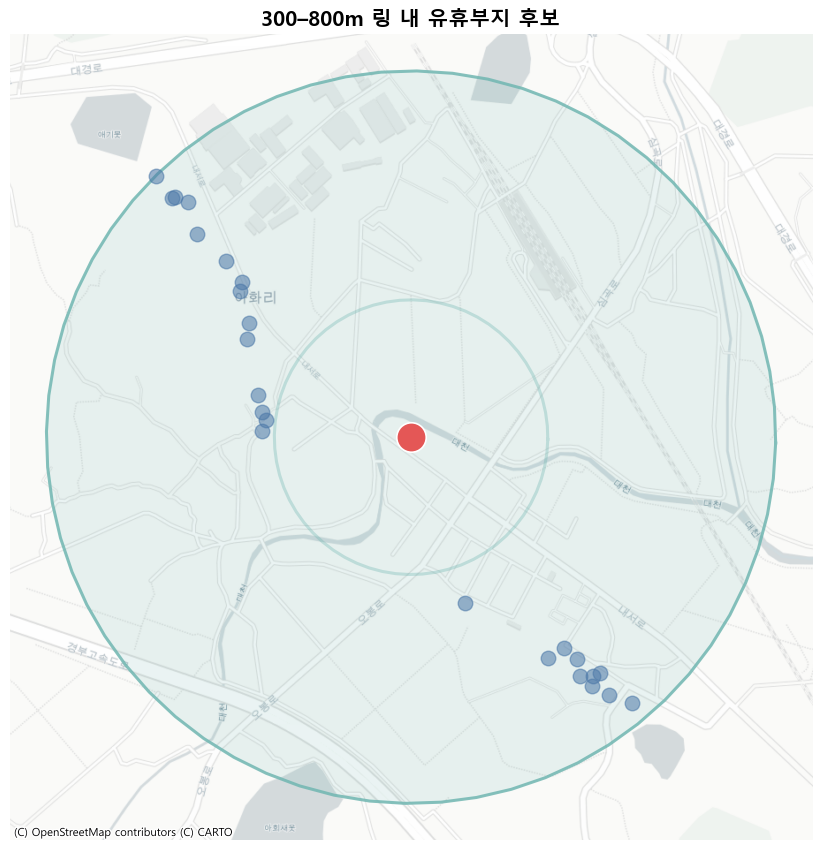

In [13]:
import matplotlib.pyplot as plt
import contextily as ctx
from matplotlib.lines import Line2D

def plot_ring_candidates(g_market_5179, ring_5179, buf300_5179, buf800_5179, g_fac_in_ring_5179,
                         title="300–800m 링 내 유휴부지 후보", outpath="viz_ring_candidates.png",
                         figsize=(8.6, 8.6)):
    g_market_3857 = g_market_5179.to_crs(3857)
    g_fac_3857 = g_fac_in_ring_5179.to_crs(3857)

    ring_3857 = gpd.GeoSeries([ring_5179], crs=5179).to_crs(3857).iloc[0]
    b300_3857 = gpd.GeoSeries([buf300_5179], crs=5179).to_crs(3857).iloc[0]
    b800_3857 = gpd.GeoSeries([buf800_5179], crs=5179).to_crs(3857).iloc[0]

    fig, ax = plt.subplots(figsize=figsize)

    ax.fill(*ring_3857.exterior.xy, alpha=0.14, zorder=2, color=COLOR_RING)
    ax.plot(*b800_3857.exterior.xy, lw=2.2, alpha=0.85, zorder=3, color=COLOR_RING)
    ax.plot(*b300_3857.exterior.xy, lw=2.2, alpha=0.35, zorder=3, color=COLOR_RING)

    if len(g_fac_3857):
        g_fac_3857.plot(ax=ax,color=COLOR_CAND, markersize=110, alpha=0.55, zorder=4)

    g_market_3857.plot(ax=ax, markersize=450, color=COLOR_MARKET, edgecolor="white", linewidth=1.2, zorder=5)

    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
    ax.set_title(title, fontsize=15, fontweight="bold")
    ax.set_axis_off()

    plt.tight_layout()
    plt.savefig(outpath, dpi=300, bbox_inches="tight")
    return fig, ax

fig, ax = plot_ring_candidates(g_market, ring, buf300, buf800, g_fac_in_ring,
                               outpath="viz_1_ring_candidates.png")
plt.show()


## 최적 입지

In [5]:
import requests
import time

API_KEY = "c4ec06aea3a95e92e9a13e9a748872bf"

HEADERS = {"Authorization": f"KakaoAK {API_KEY}"}

def kakao_walk_route(origin_lon, origin_lat, dest_lon, dest_lat,
                     priority="RECOMMEND",  # 또는 TIME, DISTANCE 등 (API 스펙에 따라)
                     sleep=0.2):
    """
    카카오 도보 경로 호출.
    반환: (dist_m, time_s, raw_json)
    - 엔드포인트/파라미터/필드는 카카오 API 스펙에 따라 조정 필요
    """

    # 예시 엔드포인트(버전에 따라 다를 수 있음)
    url = "https://apis-navi.kakaomobility.com/v1/directions"

    params = {
        "origin": f"{origin_lon},{origin_lat}",
        "destination": f"{dest_lon},{dest_lat}",
        "priority": priority,
        # 도보 옵션이 별도면 옵션/transport를 추가
    }

    r = requests.get(url, headers=HEADERS, params=params, timeout=15)
    time.sleep(sleep)

    if r.status_code != 200:
        return (None, None, {"status_code": r.status_code, "text": r.text})

    js = r.json()

    # 아래 파싱은 예시. 실제 응답 구조를 보고 필드명을 맞춰야 함.
    # 보통 route -> sections -> distance/duration 구조가 있음
    try:
        route0 = js["routes"][0]
        summary = route0.get("summary", {})
        dist_m = summary.get("distance", None)
        time_s = summary.get("duration", None)
    except Exception:
        dist_m, time_s = None, None

    return dist_m, time_s, js


In [6]:
from tqdm import tqdm

def add_kakao_walk_metrics(cand_gdf_5179, market_lat, market_lon):
    # 5179 -> 4326로 변환 (카카오 API는 WGS84 필요)
    cand_4326 = cand_gdf_5179.to_crs(4326).copy()

    dist_list = []
    time_list = []
    err_list = []

    for _, row in tqdm(cand_4326.iterrows(), total=len(cand_4326)):
        o_lat, o_lon = row.geometry.y, row.geometry.x
        d_m, t_s, raw = kakao_walk_route(
            origin_lon=o_lon, origin_lat=o_lat,
            dest_lon=market_lon, dest_lat=market_lat
        )
        dist_list.append(d_m)
        time_list.append(t_s)

        # 에러 로그
        if d_m is None or t_s is None:
            err_list.append(raw)
        else:
            err_list.append(None)

    cand_4326["kakao_walk_m"] = dist_list
    cand_4326["kakao_walk_s"] = time_list
    cand_4326["kakao_err"] = err_list

    # 다시 5179로
    cand_out_5179 = cand_4326.to_crs(5179)
    return cand_out_5179

cand_kakao_5179 = add_kakao_walk_metrics(g_fac_in_ring, market_lat, market_lon)

display(
    cand_kakao_5179[["재산 소재지","공부상 면적","사용여부","euclid_m","kakao_walk_m","kakao_walk_s"]]
    .sort_values("kakao_walk_m")
    .head(20)
)


  0%|          | 0/24 [00:00<?, ?it/s]

100%|██████████| 24/24 [00:07<00:00,  3.20it/s]


,재산 소재지,공부상 면적,사용여부,euclid_m,kakao_walk_m,kakao_walk_s
17490,경상북도 경주시 서면 아화리 411-21,1226.0,미사용,380.552390,505,124
17535,경상북도 경주시 서면 아화리 602-9,460.0,미사용,331.220874,517,91
17514,경상북도 경주시 서면 아화리 579-14,532.0,미사용,320.720290,521,92
17551,경상북도 경주시 서면 아화리 616-4,582.0,미사용,420.319546,536,63
17545,경상북도 경주시 서면 아화리 611-4,499.0,미사용,347.339441,539,97
17552,경상북도 경주시 서면 아화리 617-2,754.0,미사용,434.798140,561,65
17515,경상북도 경주시 서면 아화리 579-2,711.0,미사용,327.215298,572,104
17467,경상북도 경주시 서면 아화리 224,506.0,미사용,492.961759,628,70
17468,경상북도 경주시 서면 아화리 225-2,509.0,미사용,502.991023,644,71
17466,경상북도 경주시 서면 아화리 223-3,1345.0,미사용,560.449610,701,75


In [7]:
top3 = (
    cand_kakao_5179.dropna(subset=["kakao_walk_m"])
    .sort_values(["kakao_walk_m", "kakao_walk_s"])
    .head(3)
)

display(top3[["재산 소재지","공부상 면적","euclid_m","kakao_walk_m","kakao_walk_s"]])


,재산 소재지,공부상 면적,euclid_m,kakao_walk_m,kakao_walk_s
17490,경상북도 경주시 서면 아화리 411-21,1226.0,380.552390,505,124
17535,경상북도 경주시 서면 아화리 602-9,460.0,331.220874,517,91
17514,경상북도 경주시 서면 아화리 579-14,532.0,320.720290,521,92


### 시각화

In [14]:
from shapely.geometry import LineString

def kakao_polyline_to_linestring(js):
    """
    카카오 응답에서 경로 좌표를 꺼내 LineString으로 변환.
    실제 js 구조에 맞게 수정 필요.
    """
    # 예시: routes[0].sections[0].roads[*].vertexes = [x1,y1,x2,y2,...]
    coords = []
    try:
        roads = js["routes"][0]["sections"][0]["roads"]
        for rd in roads:
            v = rd["vertexes"]
            # v: [lon,lat, lon,lat, ...]
            for i in range(0, len(v), 2):
                coords.append((v[i], v[i+1]))
    except Exception:
        return None

    if len(coords) < 2:
        return None

    return LineString(coords)

def build_kakao_route_gdf(top_df_5179, market_lat, market_lon):
    top_4326 = top_df_5179.to_crs(4326).copy()

    geoms = []
    for _, row in top_4326.iterrows():
        o_lat, o_lon = row.geometry.y, row.geometry.x
        _, _, js = kakao_walk_route(o_lon, o_lat, market_lon, market_lat)
        ls = kakao_polyline_to_linestring(js)
        geoms.append(ls)

    g_route = gpd.GeoDataFrame(top_4326.drop(columns="geometry"), geometry=geoms, crs="EPSG:4326").to_crs(5179)
    return g_route

top3_routes_5179 = build_kakao_route_gdf(top3, market_lat, market_lon)


In [15]:
def plot_top3_kakao_routes(g_market_5179, ring_5179, buf300_5179, buf800_5179, top3_5179, routes_5179,
                           title="Top3 후보: 카카오 도보 경로 기반", outpath="viz_kakao_top3.png",
                           figsize=(9,9)):

    g_market_3857 = g_market_5179.to_crs(3857)
    top3_3857 = top3_5179.to_crs(3857)
    routes_3857 = routes_5179.dropna(subset=["geometry"]).to_crs(3857)

    ring_3857 = gpd.GeoSeries([ring_5179], crs=5179).to_crs(3857).iloc[0]
    b300_3857 = gpd.GeoSeries([buf300_5179], crs=5179).to_crs(3857).iloc[0]
    b800_3857 = gpd.GeoSeries([buf800_5179], crs=5179).to_crs(3857).iloc[0]

    fig, ax = plt.subplots(figsize=figsize)

    ax.fill(*ring_3857.exterior.xy, alpha=0.10, zorder=2, color=COLOR_RING)
    ax.plot(*b800_3857.exterior.xy, lw=2.2, alpha=0.70, zorder=3, color=COLOR_RING)
    ax.plot(*b300_3857.exterior.xy, lw=2.2, alpha=0.25, zorder=3, color=COLOR_RING)

    if len(routes_3857) > 0:
        routes_3857.plot(ax=ax, linewidth=4.0, alpha=0.90, zorder=6, color = COLOR_ROUTE)

    top3_3857.plot(ax=ax, markersize=260, color=COLOR_CAND,edgecolor="white", linewidth=1.2, zorder=7)
    g_market_3857.plot(ax=ax, markersize=420, color=COLOR_MARKET,edgecolor="white", linewidth=1.2, zorder=8)

    # extent
    xmin, ymin, xmax, ymax = ring_3857.bounds
    pad = 250
    ax.set_xlim(xmin - pad, xmax + pad)
    ax.set_ylim(ymin - pad, ymax + pad)

    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=15)

    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.set_axis_off()

    plt.tight_layout()
    plt.savefig(outpath, dpi=300, bbox_inches="tight")
    return fig, ax


In [17]:
top3

,일련번호,지역본부,재산 소재지,노선명,공부상 면적,유형분류,사용여부,24년 용도,향후 사용계획 및 추진사항,비고,lat,lon,geometry,euclid_m,kakao_walk_m,kakao_walk_s,kakao_err
17490,17491,영남본부,경상북도 경주시 서면 아화리 411-21,중앙선,1226.0,활용,미사용,미활용,공단 자산개발사업,NaN,35.891457,129.049773,POINT (1139873.859 1767203.72),380.552390,505,124,None
17535,17536,영남본부,경상북도 경주시 서면 아화리 602-9,중앙선,460.0,활용,미사용,미활용,공단 자산개발사업,NaN,35.895211,129.044835,POINT (1139421.562 1767613.015),331.220874,517,91,None
17514,17515,영남본부,경상북도 경주시 서면 아화리 579-14,중앙선,532.0,활용,미사용,미활용,공단 자산개발사업,NaN,35.895058,129.044925,POINT (1139430.001 1767596.231),320.720290,521,92,None


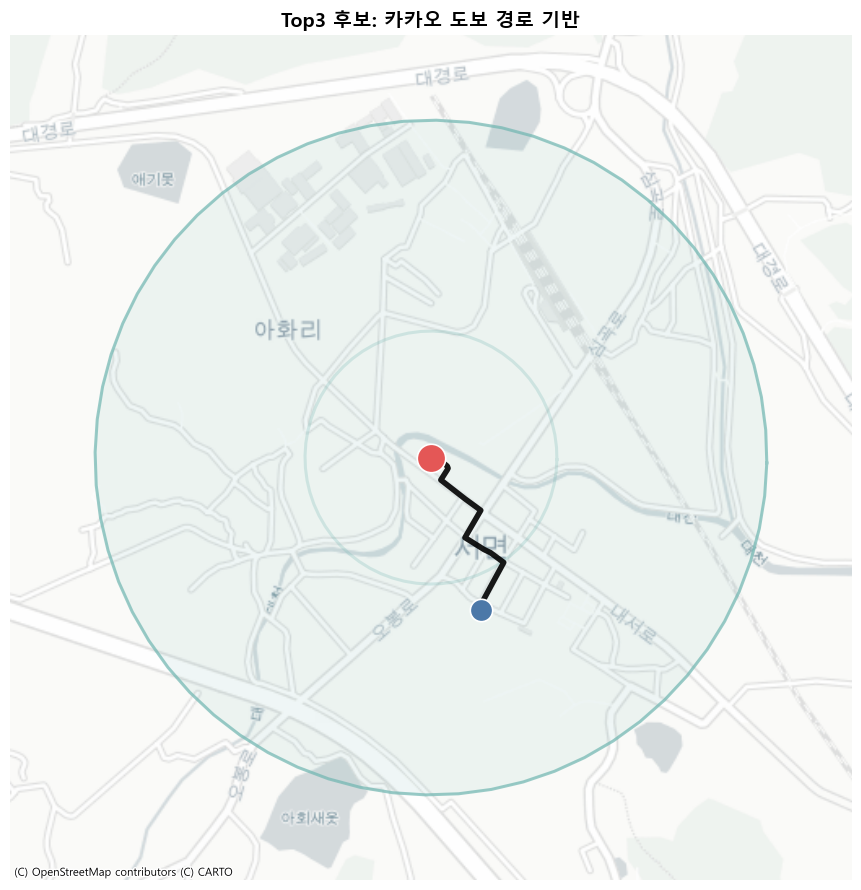

In [22]:
fig, ax = plot_top3_kakao_routes(
    g_market_5179=g_market,
    ring_5179=ring,
    buf300_5179=buf300,
    buf800_5179=buf800,
    top3_5179=top3.iloc[:1],
    routes_5179=top3_routes_5179.iloc[:1],
    outpath="viz_kakao_top3.png"
)
plt.show()

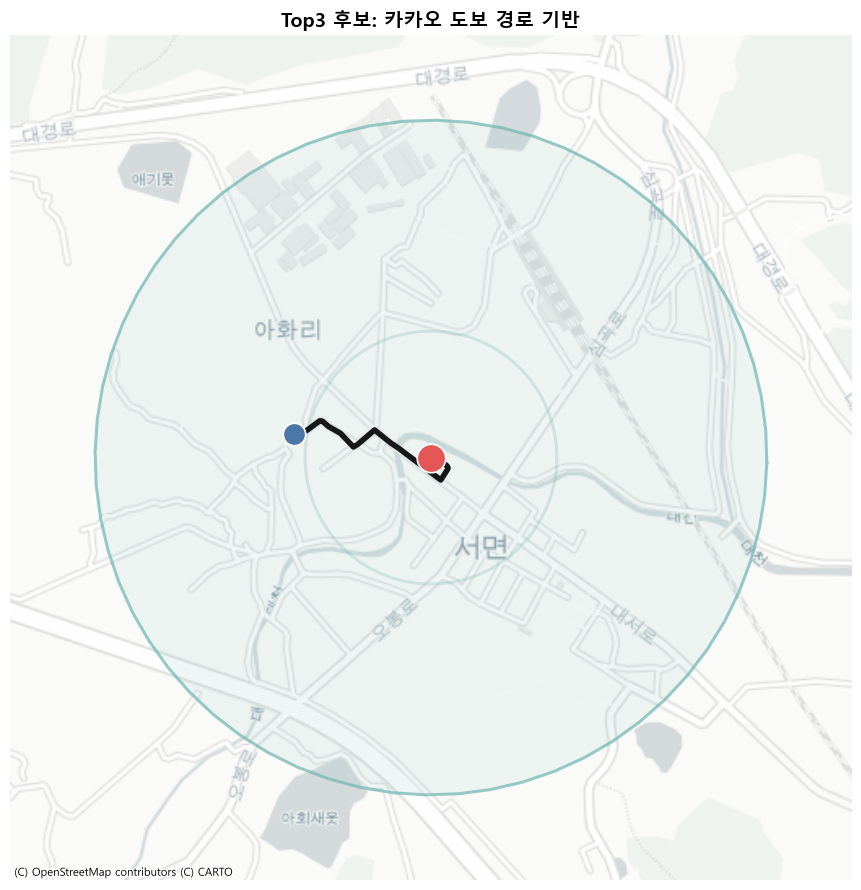

In [23]:
fig, ax = plot_top3_kakao_routes(
    g_market_5179=g_market,
    ring_5179=ring,
    buf300_5179=buf300,
    buf800_5179=buf800,
    top3_5179=top3.iloc[1:2],
    routes_5179=top3_routes_5179.iloc[1:2],
    outpath="viz_kakao_top3.png"
)
plt.show()

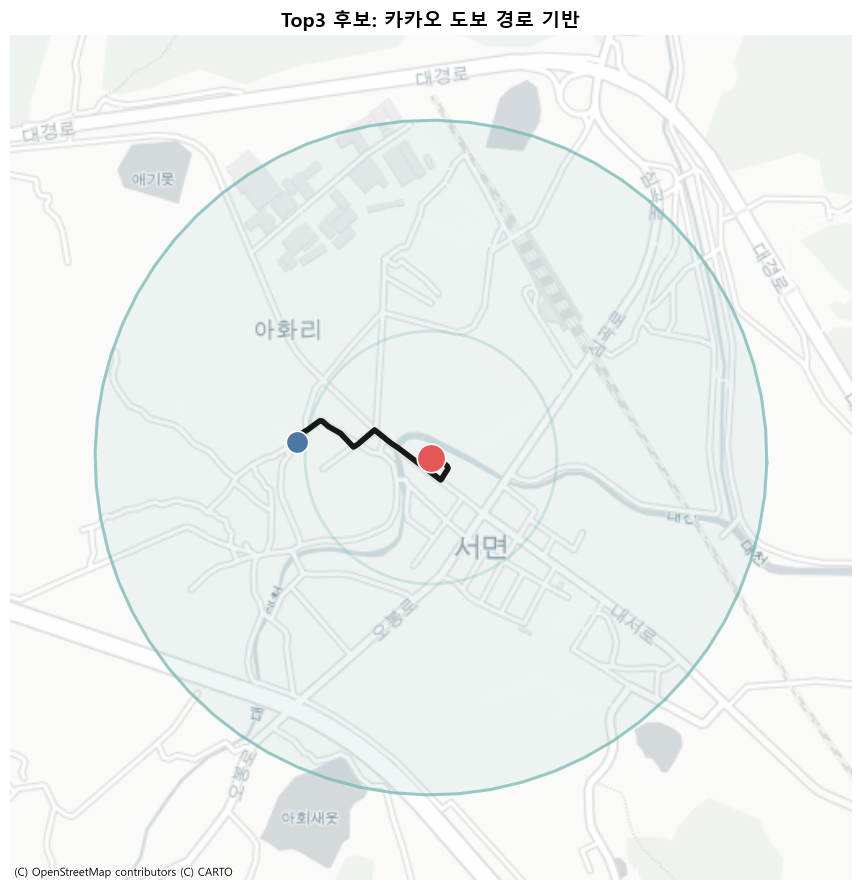

In [24]:
fig, ax = plot_top3_kakao_routes(
    g_market_5179=g_market,
    ring_5179=ring,
    buf300_5179=buf300,
    buf800_5179=buf800,
    top3_5179=top3.iloc[2:],
    routes_5179=top3_routes_5179.iloc[2:],
    outpath="viz_kakao_top3.png"
)
plt.show()